# Глава 3. Первичный анализ набора данных с изображениями
## Hard Hat Workers Dataset (v3)
**Датасет:** https://universe.roboflow.com/joseph-nelson/hard-hat-workers/dataset/3  
**Задача:** Детекция объектов — обнаружение строительных касок (helmet) и голов без касок (head)

---
## Ячейка 1. Монтирование Google Drive и распаковка датасета
Перед запуском убедитесь, что ZIP-архив датасета лежит в папке `Course_project/` на вашем Google Drive.

In [ ]:
from google.colab import drive
import zipfile
import os
import shutil

drive.mount('/content/drive')

project_dir = "/content/drive/MyDrive/Course_project/"

# Ищем ZIP-файл (можно дополнительно фильтровать по имени, если нужно)
zip_files = [f for f in os.listdir(project_dir) if f.endswith('.zip')]
if not zip_files:
    raise FileNotFoundError("ZIP-архив не найден в папке Course_project")
zip_path = os.path.join(project_dir, zip_files[0])
print(f"Архив найден: {zip_path}")

extract_path = "/content/hard-hat-dataset"

# Принудительно удаляем старую папку, чтобы распаковать заново
if os.path.exists(extract_path):
    shutil.rmtree(extract_path)
    print("Старая папка распаковки удалена.")

# Распаковываем
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Распаковка завершена.")

dataset_root = extract_path
print(f"Корневая папка датасета: {dataset_root}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Архив найден: /content/drive/MyDrive/Course_project/Hard Hat Workers.v3-v3.yolov8.zip
Старая папка распаковки удалена.
Распаковка завершена.
Корневая папка датасета: /content/hard-hat-dataset


---
## Ячейка 2. Импорт библиотек

In [ ]:
import os
import glob
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Настройки отображения
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# Соответствие id класса → название
CLASS_NAMES = {0: 'head', 1: 'helmet'}
CLASS_COLORS = {0: 'red', 1: 'green'}

print("Библиотеки импортированы успешно.")

Библиотеки импортированы успешно.


---
## Ячейка 3. Поиск папок датасета и сбор путей к файлам

In [ ]:
def find_split_dirs(root):
    """Автоматически находит папки train/test внутри датасета."""
    splits = {}
    for split in ['train', 'test', 'valid', 'val']:
        for dirpath, dirnames, _ in os.walk(root):
            if os.path.basename(dirpath).lower() == split:
                images_dir = os.path.join(dirpath, 'images')
                labels_dir = os.path.join(dirpath, 'labels')
                if os.path.exists(images_dir) and os.path.exists(labels_dir):
                    splits[split] = {'images': images_dir, 'labels': labels_dir}
                    break
    return splits

splits = find_split_dirs(dataset_root)
print(f"Найдены выборки: {list(splits.keys())}")

# Сбор путей ко всем изображениям
all_images = {}
all_labels = {}
for split, dirs in splits.items():
    imgs = sorted(glob.glob(os.path.join(dirs['images'], '*.jpg')) +
                  glob.glob(os.path.join(dirs['images'], '*.jpeg')) +
                  glob.glob(os.path.join(dirs['images'], '*.png')))
    lbls = sorted(glob.glob(os.path.join(dirs['labels'], '*.txt')))
    all_images[split] = imgs
    all_labels[split] = lbls
    print(f"  {split}: {len(imgs)} изображений, {len(lbls)} файлов аннотаций")

total_images = sum(len(v) for v in all_images.values())
print(f"\nИтого изображений: {total_images}")

Найдены выборки: ['train', 'test']
  train: 15807 изображений, 15807 файлов аннотаций
  test: 1766 изображений, 1766 файлов аннотаций

Итого изображений: 17573


---
## Ячейка 4. Оценка качества изображений
Проверка на битые файлы, нулевой размер, разрешение.

In [ ]:
def check_images(image_paths):
    """Проверяет изображения: битые файлы, размеры."""
    broken = []
    zero_size = []
    sizes = []

    for path in image_paths:
        file_size = os.path.getsize(path)
        if file_size == 0:
            zero_size.append(path)
            continue
        try:
            with Image.open(path) as img:
                sizes.append(img.size)  # (width, height)
        except Exception:
            broken.append(path)

    return broken, zero_size, sizes

print("Проверка изображений (это может занять некоторое время)...")
all_paths = [p for paths in all_images.values() for p in paths]
broken, zero_size, sizes = check_images(all_paths)

print(f"\nРезультаты проверки:")
print(f"  Всего проверено:        {len(all_paths)}")
print(f"  Битых файлов:           {len(broken)}")
print(f"  Файлов нулевого размера:{len(zero_size)}")
print(f"  Успешно открыто:        {len(sizes)}")

unique_sizes = Counter(sizes)
print(f"  Уникальных разрешений:  {len(unique_sizes)}")
for sz, cnt in unique_sizes.most_common(5):
    print(f"    {sz[0]}x{sz[1]} — {cnt} изображений")

Проверка изображений (это может занять некоторое время)...

Результаты проверки:
  Всего проверено:        17573
  Битых файлов:           0
  Файлов нулевого размера:0
  Успешно открыто:        17573
  Уникальных разрешений:  1
    600x600 — 17573 изображений


---
## Ячейка 5. Анализ количества и баланса классов
Подсчёт аннотаций по классам в каждой выборке.

In [ ]:
def count_annotations(label_paths):
    """Считает количество аннотаций каждого класса по файлам YOLO TXT."""
    class_counts = Counter()
    files_without_labels = 0
    total_annotations = 0

    for lbl_path in label_paths:
        if not os.path.exists(lbl_path):
            files_without_labels += 1
            continue
        with open(lbl_path, 'r') as f:
            lines = [l.strip() for l in f if l.strip()]
        if not lines:
            files_without_labels += 1
        for line in lines:
            parts = line.split()
            if parts:
                class_counts[int(parts[0])] += 1
                total_annotations += 1

    return class_counts, total_annotations, files_without_labels


stats = {}
for split, lbls in all_labels.items():
    counts, total, empty = count_annotations(lbls)
    stats[split] = {'counts': counts, 'total': total, 'empty': empty}
    print(f"\n=== {split.upper()} ===")
    print(f"  Файлов аннотаций:           {len(lbls)}")
    print(f"  Файлов без объектов (пусто):{empty}")
    print(f"  Всего аннотаций:            {total}")
    for cid, cname in CLASS_NAMES.items():
        n = counts.get(cid, 0)
        pct = n / total * 100 if total > 0 else 0
        print(f"  Класс {cid} ({cname}): {n} ({pct:.1f}%)")


=== TRAIN ===
  Файлов аннотаций:           15807
  Файлов без объектов (пусто):0
  Всего аннотаций:            59274
  Класс 0 (head): 14622 (24.7%)
  Класс 1 (helmet): 44652 (75.3%)

=== TEST ===
  Файлов аннотаций:           1766
  Файлов без объектов (пусто):0
  Всего аннотаций:            6666
  Класс 0 (head): 1803 (27.0%)
  Класс 1 (helmet): 4863 (73.0%)


---
## Ячейка 6. Визуализация баланса классов
Столбчатые диаграммы и круговые диаграммы для каждой выборки.

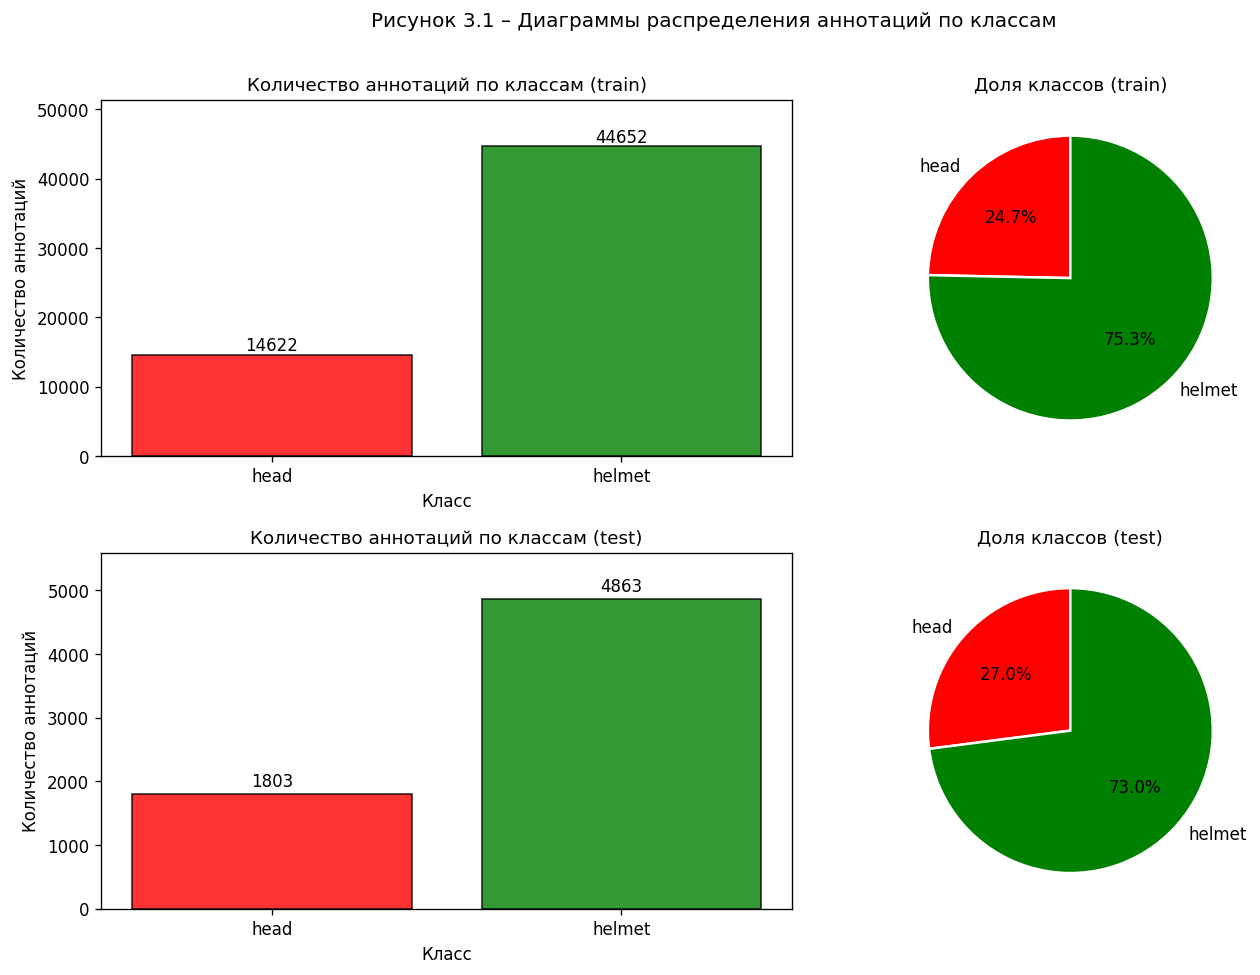

Рисунок 3.1 сохранён: /content/fig_3_1_class_balance.png


In [ ]:
n_splits = len(stats)
fig, axes = plt.subplots(n_splits, 2, figsize=(12, 4 * n_splits))
if n_splits == 1:
    axes = [axes]

for i, (split, s) in enumerate(stats.items()):
    counts = s['counts']
    names = [CLASS_NAMES.get(k, str(k)) for k in sorted(counts.keys())]
    values = [counts[k] for k in sorted(counts.keys())]
    colors = [CLASS_COLORS.get(k, 'gray') for k in sorted(counts.keys())]

    # Столбчатая диаграмма
    ax1 = axes[i][0]
    bars = ax1.bar(names, values, color=colors, alpha=0.8, edgecolor='black')
    ax1.set_title(f'Количество аннотаций по классам ({split})', fontsize=11)
    ax1.set_xlabel('Класс')
    ax1.set_ylabel('Количество аннотаций')
    for bar, val in zip(bars, values):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                 str(val), ha='center', va='bottom', fontsize=10)
    ax1.set_ylim(0, max(values) * 1.15)

    # Круговая диаграмма
    ax2 = axes[i][1]
    wedge_props = {'edgecolor': 'white', 'linewidth': 1.5}
    ax2.pie(values, labels=names, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops=wedge_props)
    ax2.set_title(f'Доля классов ({split})', fontsize=11)

plt.suptitle('Рисунок 3.1 – Диаграммы распределения аннотаций по классам',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('/content/fig_3_1_class_balance.png', bbox_inches='tight', dpi=150)
plt.show()
print("Рисунок 3.1 сохранён: /content/fig_3_1_class_balance.png")

---
## Ячейка 8. Статистика аннотаций (количество объектов на изображение)

=== TRAIN ===========
  Среднее объектов/изображение: 3.75
  Медиана:                      3.0
  Макс:                         35
  Мин:                          1
  Изображений без объектов:     0
=== TEST ===========
  Среднее объектов/изображение: 3.77
  Медиана:                      3.0
  Макс:                         28
  Мин:                          1
  Изображений без объектов:     0


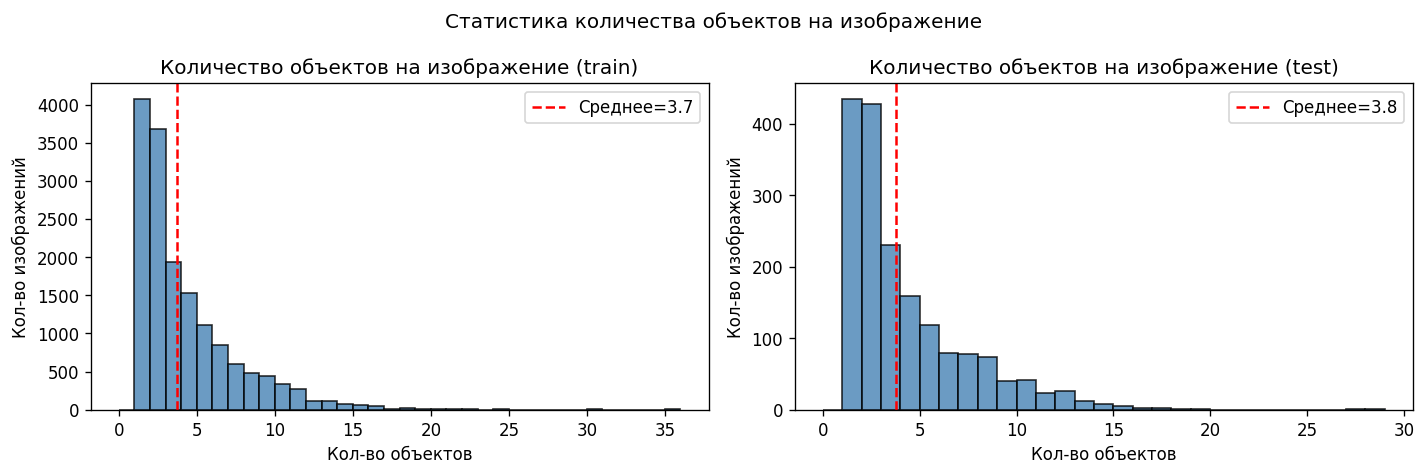

In [ ]:
def objects_per_image(label_paths):
    """Считает количество объектов на каждом изображении."""
    counts_per_img = []
    for lbl_path in label_paths:
        if not os.path.exists(lbl_path):
            counts_per_img.append(0)
            continue
        with open(lbl_path, 'r') as f:
            lines = [l.strip() for l in f if l.strip()]
        counts_per_img.append(len(lines))
    return counts_per_img


fig, axes = plt.subplots(1, len(all_labels), figsize=(6 * len(all_labels), 4))
if len(all_labels) == 1:
    axes = [axes]

for ax, (split, lbls) in zip(axes, all_labels.items()):
    opc = objects_per_image(lbls)
    arr = np.array(opc)
    print(f"=== {split.upper()} ===========")
    print(f"  Среднее объектов/изображение: {arr.mean():.2f}")
    print(f"  Медиана:                      {np.median(arr):.1f}")
    print(f"  Макс:                         {arr.max()}")
    print(f"  Мин:                          {arr.min()}")
    print(f"  Изображений без объектов:     {(arr == 0).sum()}")

    ax.hist(arr, bins=range(0, min(arr.max() + 2, 40)), color='steelblue',
            edgecolor='black', alpha=0.8)
    ax.set_title(f'Количество объектов на изображение ({split})')
    ax.set_xlabel('Кол-во объектов')
    ax.set_ylabel('Кол-во изображений')
    ax.axvline(arr.mean(), color='red', linestyle='--', label=f'Среднее={arr.mean():.1f}')
    ax.legend()

plt.suptitle('Статистика количества объектов на изображение', fontsize=12)
plt.tight_layout()
plt.savefig('/content/fig_objects_per_image.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Ячейка 9. Примеры типичных изображений
Отображение 8 случайных изображений из train с bounding box.

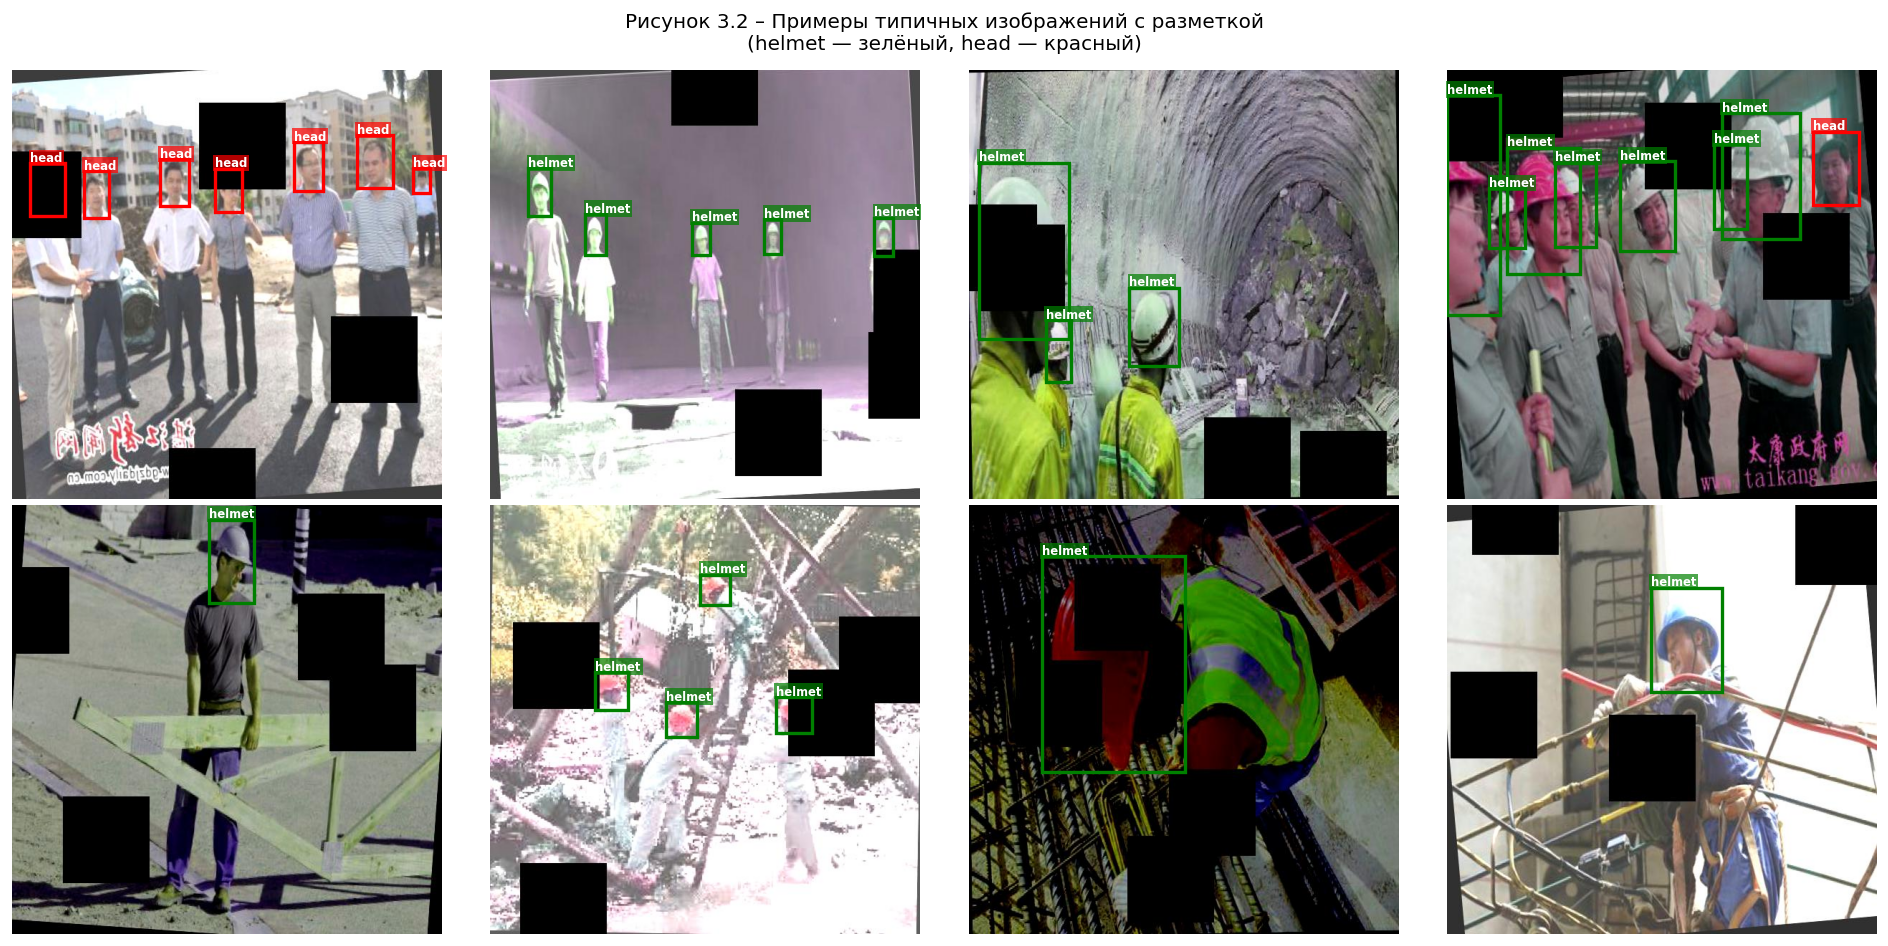

Рисунок 3.2 сохранён: /content/fig_3_2_sample_images.png


In [ ]:
def draw_bboxes(ax, img, label_path):
    """Рисует bounding boxes YOLO на изображении."""
    ax.imshow(img)
    w, h = img.size
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cid = int(parts[0])
                xc, yc, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                x1 = (xc - bw / 2) * w
                y1 = (yc - bh / 2) * h
                bw_px = bw * w
                bh_px = bh * h
                color = CLASS_COLORS.get(cid, 'yellow')
                rect = patches.Rectangle((x1, y1), bw_px, bh_px,
                                         linewidth=2, edgecolor=color, facecolor='none')
                ax.add_patch(rect)
                ax.text(x1, y1 - 3, CLASS_NAMES.get(cid, str(cid)),
                        color='white', fontsize=7, fontweight='bold',
                        bbox=dict(facecolor=color, alpha=0.7, pad=1, edgecolor='none'))
    ax.axis('off')


# Выбираем выборку для примеров (предпочтительно train)
sample_split = 'train' if 'train' in all_images else list(all_images.keys())[0]
img_paths = all_images[sample_split]
lbl_dir = splits[sample_split]['labels']

sample_paths = random.sample(img_paths, min(8, len(img_paths)))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, img_path in zip(axes, sample_paths):
    img = Image.open(img_path).convert('RGB')
    stem = Path(img_path).stem
    lbl_path = os.path.join(lbl_dir, stem + '.txt')
    draw_bboxes(ax, img, lbl_path)

plt.suptitle('Рисунок 3.2 – Примеры типичных изображений с разметкой\n'
             '(helmet — зелёный, head — красный)',
             fontsize=12)
plt.tight_layout()
plt.savefig('/content/fig_3_2_sample_images.png', bbox_inches='tight', dpi=150)
plt.show()
print("Рисунок 3.2 сохранён: /content/fig_3_2_sample_images.png")

---
## Ячейка 10. Анализ аннотаций — пример файла разметки

In [ ]:
# Показываем содержимое нескольких файлов аннотаций
sample_split = 'train' if 'train' in all_labels else list(all_labels.keys())[0]
lbl_paths = all_labels[sample_split]

# Выбираем первые 5 непустых файлов
shown = 0
print(f"Примеры файлов аннотаций YOLO TXT ({sample_split}):")
print("=" * 60)
for lp in lbl_paths:
    if not os.path.exists(lp):
        continue
    with open(lp, 'r') as f:
        content = f.read().strip()
    if not content:
        continue
    print(f"\nФайл: {os.path.basename(lp)}")
    for line in content.split('\n')[:5]:
        parts = line.split()
        if len(parts) >= 5:
            cid = int(parts[0])
            print(f"  class={parts[0]} ({CLASS_NAMES.get(cid,'?')}), "
                  f"x_c={parts[1]}, y_c={parts[2]}, w={parts[3]}, h={parts[4]}")
    shown += 1
    if shown >= 3:
        break

print("\n" + "=" * 60)
print("Формат: <class_id> <x_center> <y_center> <width> <height>")
print("Все координаты нормализованы относительно размера изображения (0..1)")
print("class 0 = head  |  class 1 = helmet")

Примеры файлов аннотаций YOLO TXT (train):

Файл: 000001_jpg.rf.063823aaf332982f3e950651f452a290.txt
  class=1 (helmet), x_c=0.3983333333333333, y_c=0.3075, w=0.11166666666666666, h=0.16333333333333333
  class=1 (helmet), x_c=0.24166666666666667, y_c=0.4375, w=0.05, h=0.08166666666666667

Файл: 000001_jpg.rf.0f6de3cb4d6f36215d869bbf4d230577.txt
  class=1 (helmet), x_c=0.605, y_c=0.30916666666666665, w=0.115, h=0.165
  class=1 (helmet), x_c=0.76, y_c=0.4425, w=0.051666666666666666, h=0.08333333333333333

Файл: 000001_jpg.rf.88f7e69ab4248790a4806cef2d956ecc.txt
  class=1 (helmet), x_c=0.585, y_c=0.2991666666666667, w=0.11, h=0.16166666666666665
  class=1 (helmet), x_c=0.7525, y_c=0.415, w=0.04833333333333333, h=0.08166666666666667

Формат: <class_id> <x_center> <y_center> <width> <height>
Все координаты нормализованы относительно размера изображения (0..1)
class 0 = head  |  class 1 = helmet


---
## Ячейка 11. Проверка целостности аннотаций (оценка качества разметки)

In [ ]:
def check_annotations_integrity(image_paths, label_dir):
    """Проверяет:
    - наличие файла аннотации для каждого изображения
    - корректность координат (в пределах 0..1)
    - принадлежность меток допустимым классам
    """
    known_classes = set(CLASS_NAMES.keys())
    missing_labels = []
    invalid_coords = []
    invalid_class = []
    total_boxes = 0

    for img_path in image_paths:
        stem = Path(img_path).stem
        lbl_path = os.path.join(label_dir, stem + '.txt')

        if not os.path.exists(lbl_path):
            missing_labels.append(img_path)
            continue

        with open(lbl_path, 'r') as f:
            lines = [l.strip() for l in f if l.strip()]

        for line in lines:
            parts = line.split()
            if len(parts) < 5:
                continue
            total_boxes += 1
            cid = int(parts[0])
            coords = [float(x) for x in parts[1:5]]

            if cid not in known_classes:
                invalid_class.append((img_path, line))

            if any(c < 0 or c > 1 for c in coords):
                invalid_coords.append((img_path, line))

    return {
        'total_images': len(image_paths),
        'missing_labels': len(missing_labels),
        'total_boxes': total_boxes,
        'invalid_coords': len(invalid_coords),
        'invalid_class': len(invalid_class),
    }


print("Проверка целостности аннотаций...")
for split in splits:
    result = check_annotations_integrity(
        all_images[split],
        splits[split]['labels']
    )
    print(f"\n=== {split.upper()} ===")
    print(f"  Изображений:                    {result['total_images']}")
    print(f"  Файлов аннотаций отсутствует:   {result['missing_labels']}")
    print(f"  Всего bounding boxes:           {result['total_boxes']}")
    print(f"  Некорректные координаты:        {result['invalid_coords']}")
    print(f"  Неизвестные классы:             {result['invalid_class']}")
    ok = result['missing_labels'] == 0 and result['invalid_coords'] == 0 and result['invalid_class'] == 0
    print(f"  Итог: {'✓ Все проверки пройдены' if ok else '⚠ Есть замечания'}")

Проверка целостности аннотаций...

=== TRAIN ===
  Изображений:                    15807
  Файлов аннотаций отсутствует:   0
  Всего bounding boxes:           59274
  Некорректные координаты:        0
  Неизвестные классы:             0
  Итог: ✓ Все проверки пройдены

=== TEST ===
  Изображений:                    1766
  Файлов аннотаций отсутствует:   0
  Всего bounding boxes:           6666
  Некорректные координаты:        0
  Неизвестные классы:             0
  Итог: ✓ Все проверки пройдены


---
## Ячейка 12. Аугментированные изображения
Показываем одно исходное изображение и несколько его аугментированных копий.  
> **Примечание:** в датасете v3 аугментированные копии уже включены в train — отдельной папки нет.  
> Для наглядности применяем аугментации программно к одному изображению.

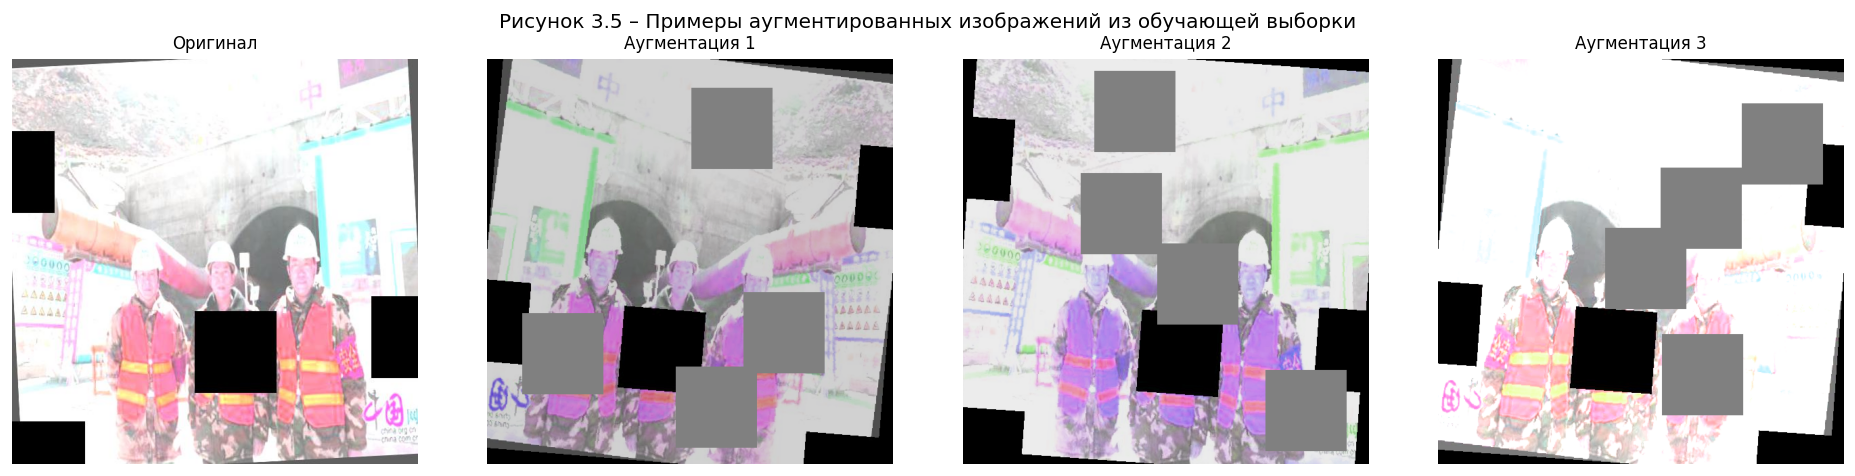

Рисунок 3.5 сохранён: /content/fig_3_5_augmentation.png


In [ ]:
import torchvision.transforms.functional as TF
import torchvision
import torch

# Берём одно случайное изображение из train
sample_split = 'train' if 'train' in all_images else list(all_images.keys())[0]
base_img_path = random.choice(all_images[sample_split])
base_img = Image.open(base_img_path).convert('RGB')

# Аугментации, соответствующие параметрам Roboflow
def augment_image(img, seed):
    random.seed(seed)
    # Горизонтальное отражение
    if random.random() > 0.5:
        img = TF.hflip(img)
    # Поворот -5..+5 градусов
    angle = random.uniform(-5, 5)
    img = TF.rotate(img, angle)
    # Яркость -40%..+40%
    brightness_factor = random.uniform(0.6, 1.4)
    img = TF.adjust_brightness(img, brightness_factor)
    # Оттенок -90..+90 (в PIL hue в [-0.5, 0.5])
    hue_factor = random.uniform(-0.25, 0.25)
    img = TF.adjust_hue(img, hue_factor)
    return img


def apply_cutout(img, n_boxes=4, box_pct=0.20):
    """Вырезает n_boxes случайных прямоугольников размером box_pct от изображения."""
    import numpy as np
    arr = np.array(img).copy()
    h, w = arr.shape[:2]
    box_h = int(h * box_pct)
    box_w = int(w * box_pct)
    for _ in range(n_boxes):
        y = random.randint(0, h - box_h)
        x = random.randint(0, w - box_w)
        arr[y:y+box_h, x:x+box_w] = 128  # серый
    return Image.fromarray(arr)


aug_images = [base_img]
for seed in [42, 123, 999]:
    aug = augment_image(base_img.copy(), seed)
    aug = apply_cutout(aug)
    aug_images.append(aug)

titles = ['Оригинал', 'Аугментация 1', 'Аугментация 2', 'Аугментация 3']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img, title in zip(axes, aug_images, titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.suptitle('Рисунок 3.5 – Примеры аугментированных изображений из обучающей выборки',
             fontsize=12)
plt.tight_layout()
plt.savefig('/content/fig_3_5_augmentation.png', bbox_inches='tight', dpi=150)
plt.show()
print("Рисунок 3.5 сохранён: /content/fig_3_5_augmentation.png")

---
## Ячейка 13. Сводная таблица статистики

In [ ]:
rows = []
for split, s in stats.items():
    for cid, cname in CLASS_NAMES.items():
        n = s['counts'].get(cid, 0)
        pct = n / s['total'] * 100 if s['total'] > 0 else 0
        rows.append({
            'Выборка': split,
            'ID класса': cid,
            'Класс': cname,
            'Кол-во аннотаций': n,
            'Доля, %': f"{pct:.1f}"
        })

df = pd.DataFrame(rows)
print("Таблица 3.1 – Распределение аннотаций по классам")
print("=" * 55)
print(df.to_string(index=False))

Таблица 3.1 – Распределение аннотаций по классам
Выборка  ID класса  Класс  Кол-во аннотаций Доля, %
  train          0   head             14622    24.7
  train          1 helmet             44652    75.3
   test          0   head              1803    27.0
   test          1 helmet              4863    73.0
